# Prédiction de WMI — pipeline propre

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, RepeatedKFold, KFold, cross_validate,
    learning_curve, GridSearchCV,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pd.set_option("display.precision", 3)

## Chargement des données

In [22]:
filepath = r"C:\Users\melan\DESU_DATA_2026\ProjetNR\data2026.xlsx"
raw_df = pd.read_excel(filepath, engine="openpyxl", sheet_name='Total2', header=0,
                       na_values=['na', 'NaN', 'NA', 'N/A', 'n/a', 'nan'])
raw_df.head()
raw_df.shape

(65, 18)

## Split train / test — AVANT tout pretraitement

Règle d'or : **aucune information du test (y compris la cible) ne doit jamais entrer dans
le fit d'un encodeur, d'un imputer, d'un scaler ou d'un modèle.**
On sépare donc X (prédicteurs uniquement, sans la cible) et y (la cible), puis on fait le split.

In [23]:
TARGET_COLUMN = "WMI"
PREDICTOR_COLUMNS = ["P300", "P600", "LNC", "N400", "LRC", "OB", "ON", "Hipp"]

X = raw_df[PREDICTOR_COLUMNS].copy()
y = raw_df[TARGET_COLUMN].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(f"Cible : {TARGET_COLUMN}")
print(f"Train : {X_train.shape[0]} patients | Test : {X_test.shape[0]} patients")

Cible : WMI
Train : 58 patients | Test : 7 patients


## Encodage de `Hipp`

L'encodeur est **fit uniquement sur `X_train`**, puis simplement appliqué (`transform`) sur
`X_test` avec `handle_unknown="ignore"` au cas où une catégorie rare n'apparaîtrait que dans le test.

In [24]:
def encode_hipp(df, encoder, fit=False):
    df = df.copy()
    if fit:
        encoded = encoder.fit_transform(df[["Hipp"]])
    else:
        encoded = encoder.transform(df[["Hipp"]])
    hipp_columns = encoder.get_feature_names_out(["Hipp"])
    encoded_df = pd.DataFrame(encoded, columns=hipp_columns, index=df.index)
    return pd.concat([df.drop(columns=["Hipp"]), encoded_df], axis=1)

hipp_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train = encode_hipp(X_train, hipp_encoder, fit=True)
X_test = encode_hipp(X_test, hipp_encoder, fit=False)

X_train.head()

,P300,P600,LNC,N400,LRC,OB,ON,Hipp_NI,Hipp_ZE,Hipp_ZP
12,-125.3,92.5,-21.6,-54.0,11.2,NaN,NaN,1.0,0.0,0.0
64,-48.4,33.7,-53.2,NaN,NaN,NaN,NaN,0.0,0.0,1.0
30,0.0,113.2,-73.1,NaN,NaN,1,81/81,0.0,0.0,1.0
33,0.0,168.0,-74.2,-11.0,0.0,98%,80/77,0.0,1.0,0.0
9,-105.0,79.3,-18.8,NaN,NaN,0.94,68/43,1.0,0.0,0.0


## Nettoyage des données (colonnes trop incomplètes)

Le seuil de suppression est calculé **uniquement sur `X_train`**, puis la même liste de colonnes
est retirée de `X_test` — sans jamais regarder les valeurs du test pour décider quoi supprimer.

In [25]:
percent_missing = X_train.isnull().sum() * 100 / len(X_train)
percent_missing.sort_values(ascending=False, inplace=True)
percent_missing

ON         60.345
OB         58.621
LRC        36.207
N400       36.207
P600        3.448
P300        3.448
LNC         3.448
Hipp_NI     0.000
Hipp_ZE     0.000
Hipp_ZP     0.000
dtype: float64

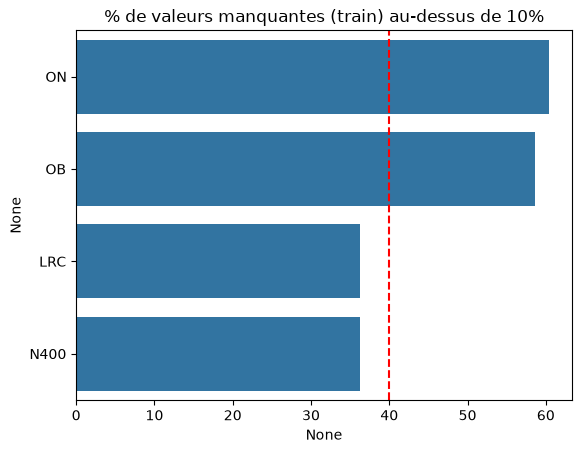

In [26]:
threshold_view = 10
filtered = percent_missing[percent_missing.values > threshold_view]

threshold = 40
if len(filtered) > 0:
    ax = sns.barplot(x=filtered, y=filtered.index, orient='h')
    ax.set_title(f"% de valeurs manquantes (train) au-dessus de {threshold_view}%")
    ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")
else:
    print("Aucune colonne au-dessus du seuil d'affichage.")

In [27]:
columns_to_drop = percent_missing[percent_missing.values > threshold].index

X_train = X_train.drop(columns=columns_to_drop, errors="ignore")
X_test = X_test.drop(columns=columns_to_drop, errors="ignore")

print(f"Colonnes supprimées (> {threshold}% manquant sur le train) : {list(columns_to_drop)}")
X_train.shape, X_test.shape

Colonnes supprimées (> 40% manquant sur le train) : ['ON', 'OB']


((58, 8), (7, 8))

## Imputation des valeurs manquantes

**Point critique :** le `KNNImputer` est fit **uniquement sur les prédicteurs de `X_train`**
(jamais sur la cible). Le même imputer, déjà entraîné, est ensuite juste appliqué (`transform`,
pas `fit_transform`) sur `X_test`.

In [28]:
numeric_columns = X_train.select_dtypes(include=["float", "int"]).columns

imputer = KNNImputer(missing_values=np.nan)
imputer.fit(X_train[numeric_columns])

X_train_imputed = X_train.copy()
X_train_imputed[numeric_columns] = imputer.transform(X_train[numeric_columns])

X_test_imputed = X_test.copy()
X_test_imputed[numeric_columns] = imputer.transform(X_test[numeric_columns])

X_train_imputed.shape, X_test_imputed.shape

((58, 8), (7, 8))

### Retirer les lignes où la cible (`WMI`) est manquante

On n'impute jamais la variable à prédire : impossible d'entraîner ou d'évaluer sur une ligne
dont on ne connaît pas la vraie réponse. On filtre donc train et test séparément.

In [29]:
train_mask = y_train.notna()
test_mask = y_test.notna()

print(f"Lignes retirées (train, {TARGET_COLUMN} manquant) : {(~train_mask).sum()}")
print(f"Lignes retirées (test, {TARGET_COLUMN} manquant)  : {(~test_mask).sum()}")

X_train_imputed = X_train_imputed.loc[train_mask]
y_train = y_train.loc[train_mask]

X_test_imputed = X_test_imputed.loc[test_mask]
y_test = y_test.loc[test_mask]

print(f"Train final : {X_train_imputed.shape[0]} patients | Test final : {X_test_imputed.shape[0]} patients")

Lignes retirées (train, WMI manquant) : 2
Lignes retirées (test, WMI manquant)  : 0
Train final : 56 patients | Test final : 7 patients


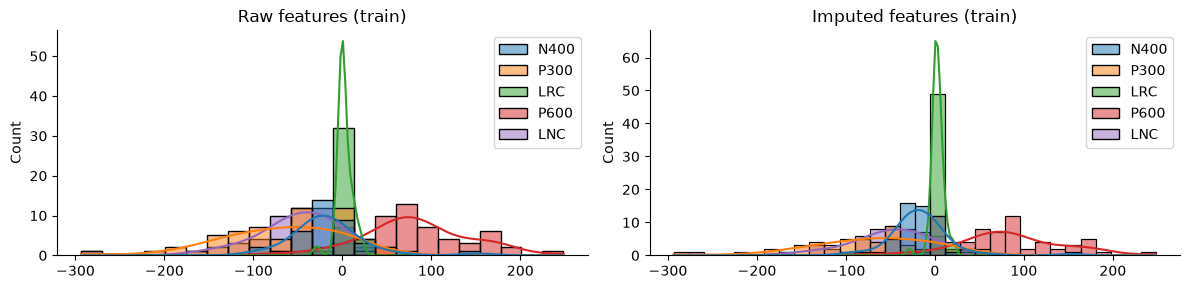

In [30]:
def compare_dist(features):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    sns.histplot(X_train.loc[:, features], kde=True, ax=axes[0])
    axes[0].set_title("Raw features (train)")
    sns.histplot(X_train_imputed.loc[:, features], kde=True, ax=axes[1])
    axes[1].set_title("Imputed features (train)")
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

compare_dist(["N400", "P300", "LRC", "P600", "LNC"])

## Plot représentation train

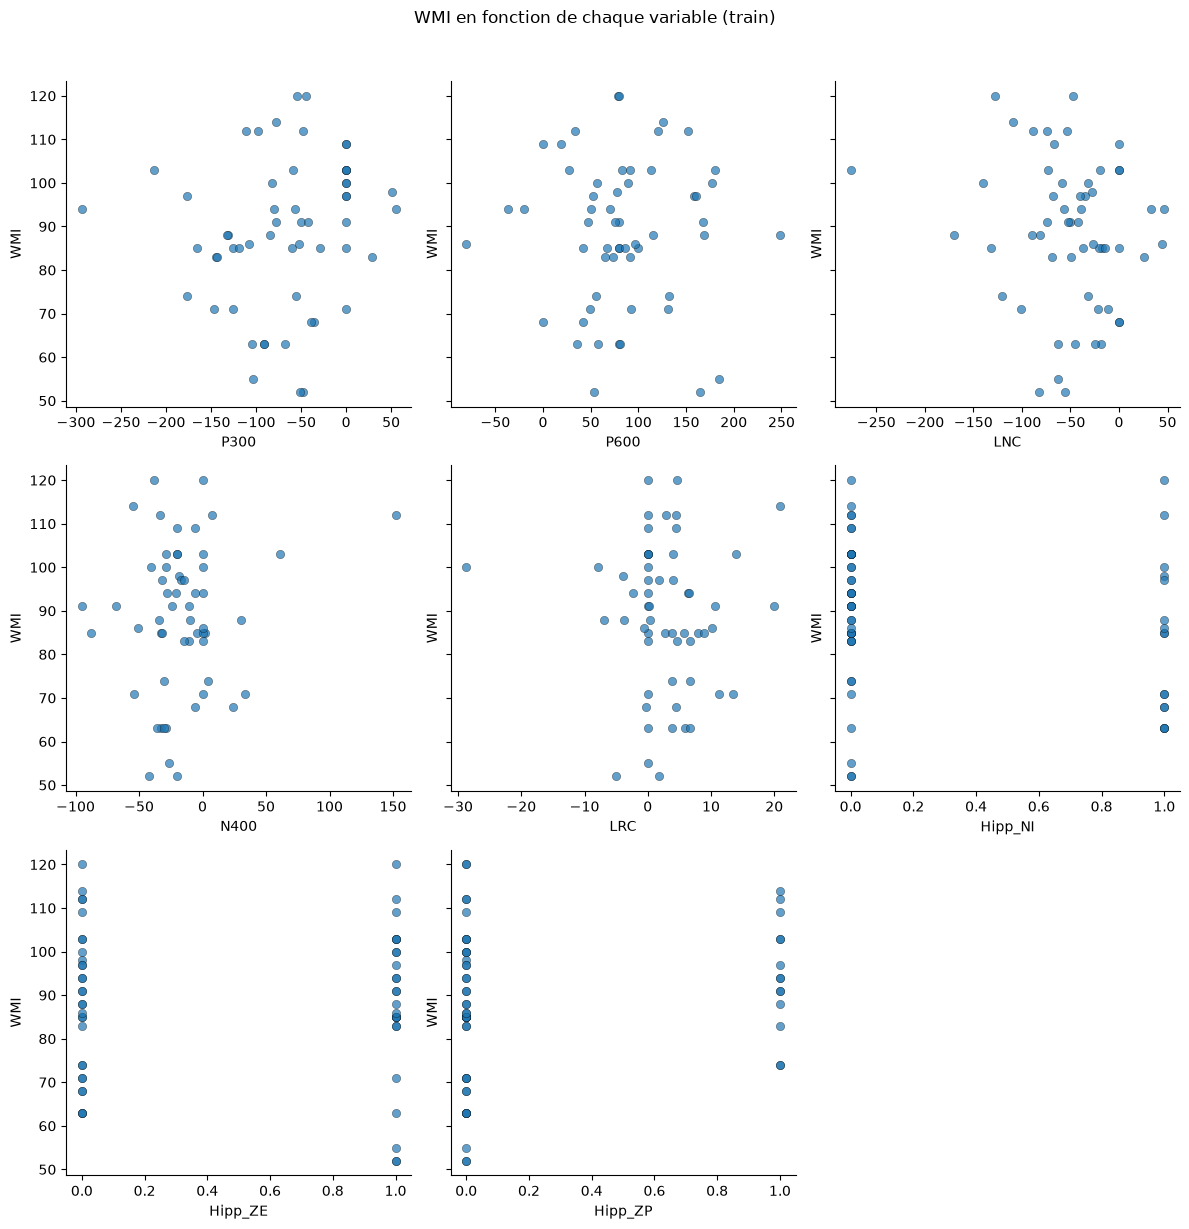

In [48]:
n_cols = 3
n_rows = int(np.ceil(len(X_train_imputed.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharey=True)
axes = axes.flatten()

for ax, feature in zip(axes, X_train_imputed.columns):
    ax.scatter(X_train_imputed[feature], y_train, alpha=0.7, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(feature)
    ax.set_ylabel("WMI")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[len(X_train_imputed.columns):]:
    ax.axis("off")

fig.suptitle("WMI en fonction de chaque variable (train)", y=1.02)
plt.tight_layout()
plt.show()

## Réduction de dimensions : ACP

In [53]:
from sklearn import preprocessing

std_scale = preprocessing.StandardScaler().fit(X_train_imputed)
X_train_scaled = std_scale.transform(X_train_imputed)
X_test_scaled = std_scale.transform(X_test_imputed)

In [54]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=X_train_scaled.shape[1])
pca.fit(X_train_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",8
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

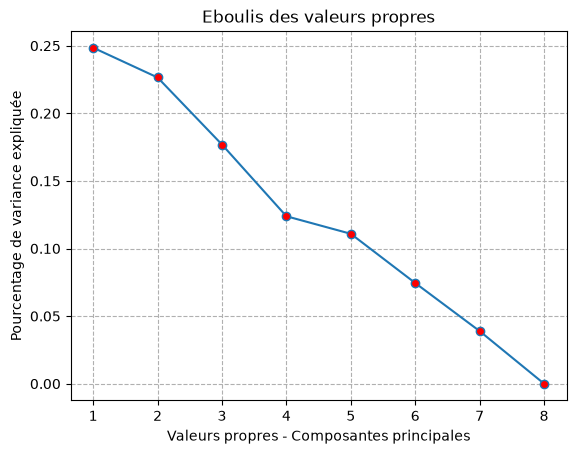

In [55]:
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.plot(range(1,X_train_imputed.shape[1]+1), pca.explained_variance_ratio_, marker="o", markerfacecolor="r")
plt.xlabel('Valeurs propres - Composantes principales'); 
plt.xticks(range(1,X_train_imputed.shape[1]+1))
plt.ylabel('Pourcentage de variance expliquée');
plt.grid(linestyle='--')
plt.title("Eboulis des valeurs propres");

In [57]:
print(pca.explained_variance_ratio_[0:5].sum())

0.8866358897545579


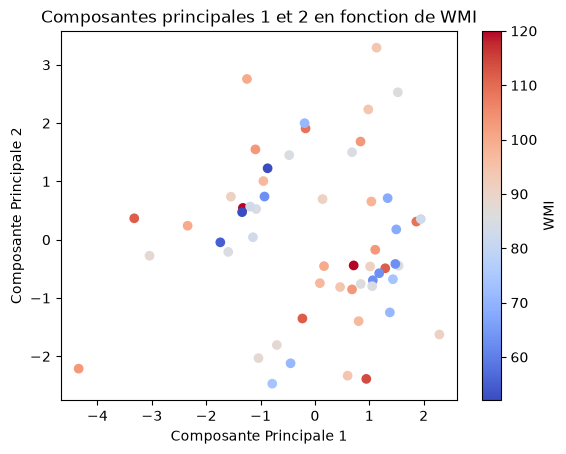

In [59]:
# projeter X sur les composantes principales
X_projected = pca.transform(X_train_scaled)

# afficher chaque observation des deux 1eres composantes
plt.scatter(X_projected[:, 0], X_projected[:, 1],
    # colorer en utilisant la variable cible WMI (train, déjà filtrée/alignée)
    c=y_train, cmap='coolwarm')

plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.title("Composantes principales 1 et 2 en fonction de WMI")
plt.colorbar(label="WMI")
plt.show()

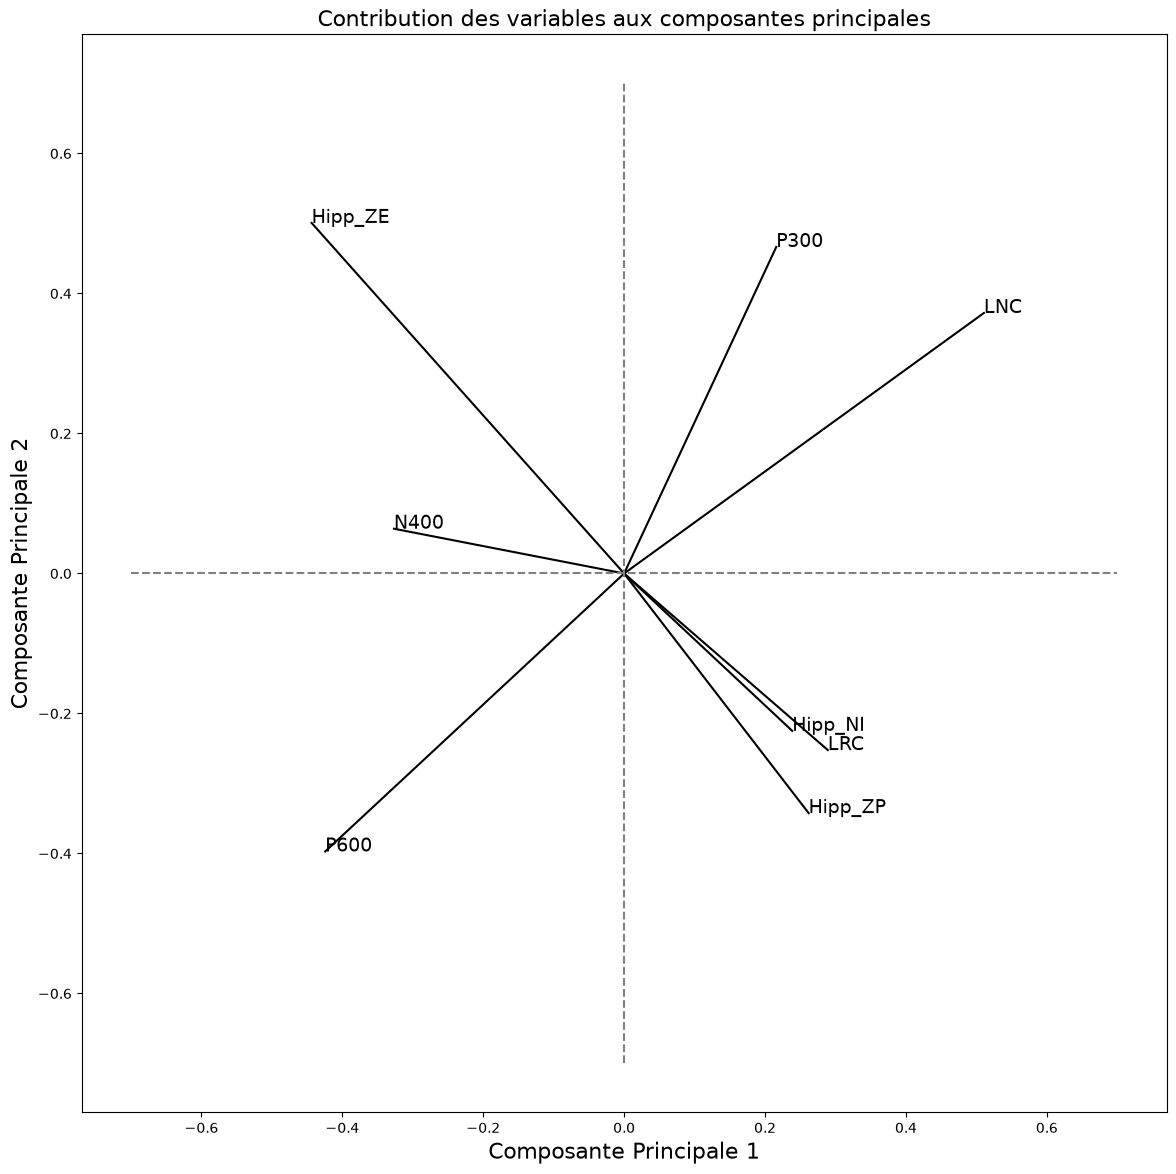

In [61]:
pcs = pca.components_
fig, ax = plt.subplots(1,figsize=(14,14))
for i, (x, y) in enumerate(zip(pcs[0, :], pcs[1, :])):
    # Afficher un segment de l'origine au point (x, y)
    ax.plot([0, x], [0, y], color='k')
    # Afficher le nom (data.columns[i]) de la performance
    ax.text(x, y, X_train_imputed.columns[i], fontsize='14');

# Afficher une ligne horizontale y=0
plt.plot([-0.7, 0.7], [0, 0], color='grey', ls='--');

# Afficher une ligne verticale x=0
plt.plot([0, 0], [-0.7, 0.7], color='grey', ls='--');

ax.set_xlabel("Composante Principale 1", fontsize = 16);
ax.set_ylabel("Composante Principale 2", fontsize = 16);
ax.set_title("Contribution des variables aux composantes principales", fontsize = 16);

## Comparaison des modèles — validation croisée strictement sur le TRAIN

Le `StandardScaler` reste dans la `Pipeline` pour être re-fit à chaque pli de la CV.
Le test (`X_test_imputed`, `y_test`) reste intouché jusqu'à l'évaluation finale.

In [62]:
from sklearn.model_selection import KFold

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=0.5),
    "Lasso": Lasso(alpha=0.5, max_iter=10000),
    "Elastic Net": ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=10000),
    "PLS Regression": PLSRegression(n_components=2),
    "SVR (default)": SVR(kernel="rbf", C=1, epsilon=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(name, model, X, y, cv):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model),
    ])
    scores = cross_validate(
        pipeline, X, y, cv=cv,
        scoring={"R2": "r2", "RMSE": "neg_root_mean_squared_error", "MAE": "neg_mean_absolute_error"},
        return_train_score=False,
    )
    return {
        "Model": name,
        "R2_mean": np.mean(scores["test_R2"]),
        "R2_std": np.std(scores["test_R2"]),
        "RMSE_mean": -np.mean(scores["test_RMSE"]),
        "MAE_mean": -np.mean(scores["test_MAE"]),
    }

results = [evaluate_model(name, model, X_train_imputed, np.ravel(y_train), cv)
           for name, model in models.items()]

results_df = pd.DataFrame(results).sort_values("R2_mean", ascending=False).reset_index(drop=True)
results_df

,Model,R2_mean,R2_std,RMSE_mean,MAE_mean
0,SVR (default),-0.051,0.046,16.441,13.255
1,Elastic Net,-0.155,0.127,17.121,14.215
2,PLS Regression,-0.214,0.257,17.234,14.277
3,Lasso,-0.215,0.218,17.444,14.682
4,Ridge,-0.288,0.319,17.794,15.088
5,Linear Regression,-0.300,0.334,17.858,15.157
6,Random Forest,-0.518,0.209,19.505,15.966
7,Gradient Boosting,-0.896,0.539,21.509,17.229


## Optimisation des hyperparamètres du SVR (GridSearchCV)

Le SVR par défaut performait mal — avant de l'écarter, on cherche ses meilleurs hyperparamètres
sur une grille raisonnable, avec une CV plus légère (adaptée à un petit échantillon).

In [50]:
param_grid = {
    "model__C": [0.1, 1, 10],
    "model__epsilon": [0.1, 0.5],
    "model__gamma": ["scale", "auto"],
    "model__kernel": ["rbf", "linear"],
}

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR()),
])

cv_grid = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    svr_pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=cv_grid,
    n_jobs=1,   # séquentiel : évite les blocages multiprocessing sous Windows/VS Code
)

grid_search.fit(X_train_imputed, np.ravel(y_train))

print("Meilleurs hyperparamètres SVR :", grid_search.best_params_)
print(f"Meilleur R² moyen (CV, train) : {grid_search.best_score_:.3f}")

best_svr = grid_search.best_estimator_.named_steps["model"]
models["SVR (tuned)"] = best_svr

Meilleurs hyperparamètres SVR : {'model__C': 1, 'model__epsilon': 0.5, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Meilleur R² moyen (CV, train) : -0.048


### Tableau de résultats mis à jour (avec le SVR réglé)

In [33]:
svr_tuned_result = evaluate_model("SVR (tuned)", best_svr, X_train_imputed, np.ravel(y_train), cv)

results_df = pd.concat(
    [results_df[results_df["Model"] != "SVR (tuned)"], pd.DataFrame([svr_tuned_result])],
    ignore_index=True,
).sort_values("R2_mean", ascending=False).reset_index(drop=True)

results_df

,Model,R2_mean,R2_std,RMSE_mean,MAE_mean
0,SVR (tuned),-0.117,0.267,16.383,13.223
1,SVR (default),-0.119,0.270,16.399,13.234
2,Elastic Net,-0.318,0.501,17.414,14.565
3,PLS Regression,-0.337,0.511,17.499,14.482
4,Ridge,-0.347,0.530,17.557,14.717
5,Lasso,-0.348,0.527,17.566,14.728
6,Linear Regression,-0.368,0.552,17.668,14.833
7,Random Forest,-0.564,0.511,19.120,15.514
8,Gradient Boosting,-0.980,0.766,21.259,17.160


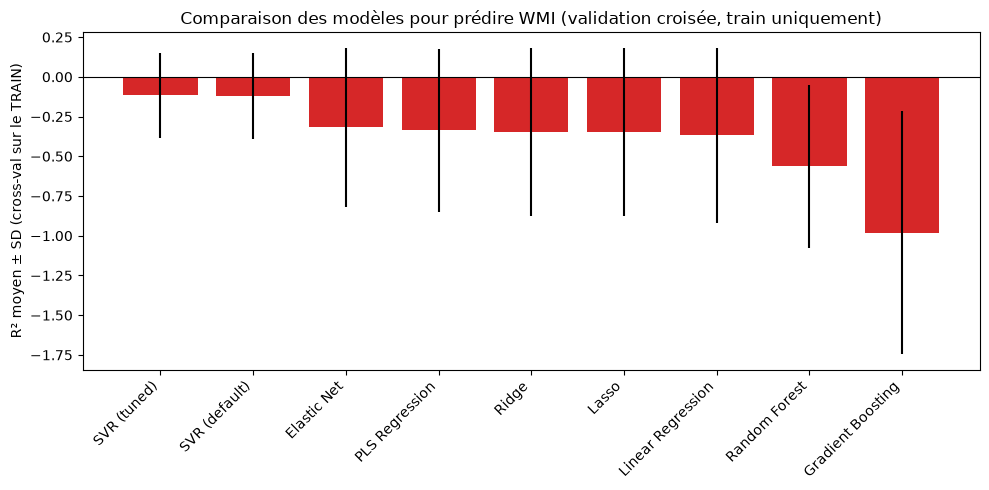

In [34]:
plt.figure(figsize=(10, 5))
colors = ["#2ca02c" if r2 >= 0 else "#d62728" for r2 in results_df["R2_mean"]]
plt.bar(results_df["Model"], results_df["R2_mean"], yerr=results_df["R2_std"], color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45, ha="right")
plt.ylabel("R² moyen ± SD (cross-val sur le TRAIN)")
plt.title(f"Comparaison des modèles pour prédire {TARGET_COLUMN} (validation croisée, train uniquement)")
plt.tight_layout()
plt.show()

## Sélection du meilleur modèle et évaluation UNIQUE sur le test

Le modèle est choisi selon le meilleur `R2_mean` en CV **sur le train**. On l'entraîne
ensuite une seule fois sur tout le train, puis on l'évalue **une seule fois** sur le test —
la seule métrique qui compte pour juger de la performance réelle hors échantillon.

In [35]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", best_model),
])

final_pipeline.fit(X_train_imputed, np.ravel(y_train))
y_pred_test = final_pipeline.predict(X_test_imputed)

test_r2 = r2_score(y_test, y_pred_test)
test_rmse = root_mean_squared_error(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)

summary_test = pd.DataFrame([{
    "Modèle retenu": best_model_name,
    "R² (test)": round(test_r2, 3),
    "RMSE (test)": round(test_rmse, 3),
    "MAE (test)": round(test_mae, 3),
    "R² CV (train)": round(results_df.iloc[0]["R2_mean"], 3),
}])
summary_test

,Modèle retenu,R² (test),RMSE (test),MAE (test),R² CV (train)
0,SVR (tuned),-0.186,13.272,10.406,-0.117


### Visualisation : valeurs prédites vs valeurs réelles (test)

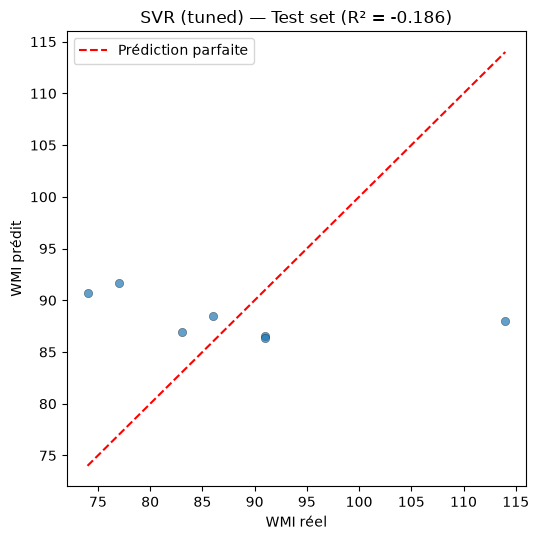

In [36]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, y_pred_test, alpha=0.7, edgecolor="k", linewidth=0.3)

lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, "r--", label="Prédiction parfaite")

ax.set_xlabel(f"{TARGET_COLUMN} réel")
ax.set_ylabel(f"{TARGET_COLUMN} prédit")
ax.set_title(f"{best_model_name} — Test set (R² = {test_r2:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

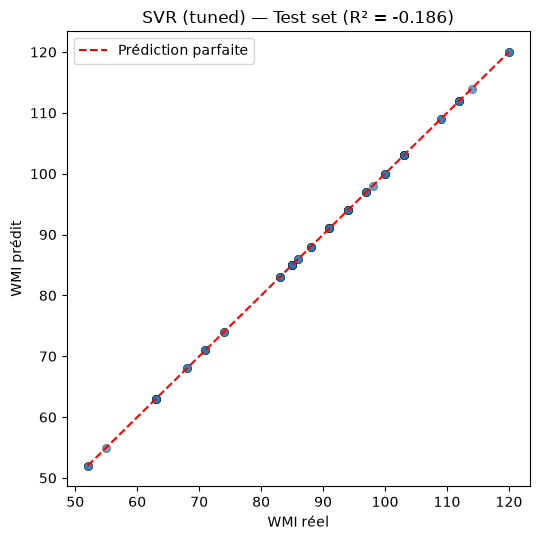

In [39]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_train, y_train, alpha=0.7, edgecolor="k", linewidth=0.3)

lims = [min(y_train.min(), y_train.min()), max(y_train.max(), y_train.max())]
ax.plot(lims, lims, "r--", label="Prédiction parfaite")

ax.set_xlabel(f"{TARGET_COLUMN} réel")
ax.set_ylabel(f"{TARGET_COLUMN} prédit")
ax.set_title(f"{best_model_name} — Test set (R² = {test_r2:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

## Learning curve du modèle réellement retenu (sur le train)

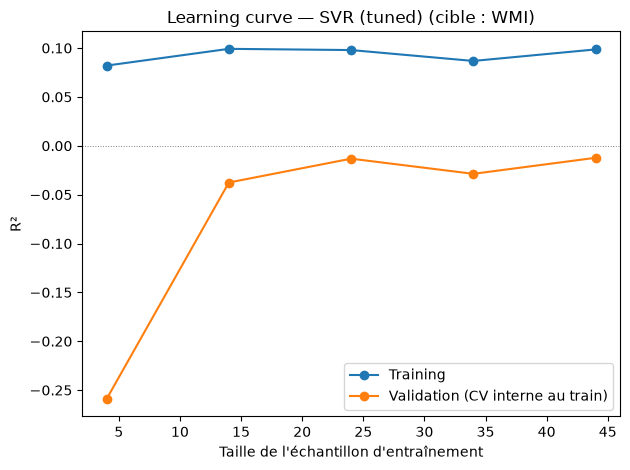

In [37]:
train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline,
    X_train_imputed,
    np.ravel(y_train),
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 5),
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), marker="o", label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), marker="o", label="Validation (CV interne au train)")
plt.axhline(0, color="grey", linewidth=0.7, linestyle=":")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("R²")
plt.title(f"Learning curve — {best_model_name} (cible : {TARGET_COLUMN})")
plt.legend()
plt.tight_layout()
plt.show()

## Résumé final

In [38]:
print(f"Cible prédite : {TARGET_COLUMN}")
print(f"Échantillon   : {X_train_imputed.shape[0]} (train) / {X_test_imputed.shape[0]} (test)")
print()
print("Classement des modèles (CV sur le train) :")
print(results_df.to_string(index=False))
print()
print("Performance du modèle retenu sur le test (jamais vu avant) :")
print(summary_test.to_string(index=False))

Cible prédite : WMI
Échantillon   : 56 (train) / 7 (test)

Classement des modèles (CV sur le train) :
            Model  R2_mean  R2_std  RMSE_mean  MAE_mean
      SVR (tuned)   -0.117   0.267     16.383    13.223
    SVR (default)   -0.119   0.270     16.399    13.234
      Elastic Net   -0.318   0.501     17.414    14.565
   PLS Regression   -0.337   0.511     17.499    14.482
            Ridge   -0.347   0.530     17.557    14.717
            Lasso   -0.348   0.527     17.566    14.728
Linear Regression   -0.368   0.552     17.668    14.833
    Random Forest   -0.564   0.511     19.120    15.514
Gradient Boosting   -0.980   0.766     21.259    17.160

Performance du modèle retenu sur le test (jamais vu avant) :
Modèle retenu  R² (test)  RMSE (test)  MAE (test)  R² CV (train)
  SVR (tuned)     -0.186       13.272      10.406         -0.117
